In [1]:
# 安装所需软件包

!pip install -U langgraph langsmith

  Using cached langsmith-0.7.16-py3-none-any.whl.metadata (15 kB)
Using cached langsmith-0.7.16-py3-none-any.whl (347 kB)
  Attempting uninstall: langsmith
    Found existing installation: langsmith 0.7.11
    Uninstalling langsmith-0.7.11:
      Successfully uninstalled langsmith-0.7.11


In [14]:
# langgraph Hello World（使用 langchain.agents.create_agent，替代已弃用的 create_react_agent）
from langchain.agents import create_agent
from langchain_community.chat_models import ChatTongyi

llm = ChatTongyi(
    model_name="qwen-turbo",
    temperature=0.7,
    streaming=True
)

agent = create_agent(
    model=llm,
    tools=[],
    system_prompt="You are a helpful assistant."
)

# 入参为 messages（复数），create_agent 与 create_react_agent 的 message 格式一致
# agent.invoke({"messages": [{"role": "user", "content": "Hello, how can I help you?"}]})
for chunk in agent.stream(
    {"messages": [{"role": "user", "content": "你是谁？"}]},
    stream_mode="messages"
):
    print(chunk)
    print("\n")

(AIMessageChunk(content='我是', additional_kwargs={}, response_metadata={}, id='lc_run--019cd7e5-e520-7ed1-8305-d7707fa9c1c3', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[]), {'langgraph_step': 1, 'langgraph_node': 'model', 'langgraph_triggers': ('branch:to:model',), 'langgraph_path': ('__pregel_pull', 'model'), 'langgraph_checkpoint_ns': 'model:bfa90725-75db-4b38-ce49-78b3c56d33e7', 'checkpoint_ns': 'model:bfa90725-75db-4b38-ce49-78b3c56d33e7', 'ls_provider': 'tongyi', 'ls_model_type': 'chat', 'ls_model_name': 'qwen-turbo'})


(AIMessageChunk(content='通', additional_kwargs={}, response_metadata={}, id='lc_run--019cd7e5-e520-7ed1-8305-d7707fa9c1c3', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[]), {'langgraph_step': 1, 'langgraph_node': 'model', 'langgraph_triggers': ('branch:to:model',), 'langgraph_path': ('__pregel_pull', 'model'), 'langgraph_checkpoint_ns': 'model:bfa90725-75db-4b38-ce49-78b3c56d33e7', 'checkpoint_ns': 'model:bfa90725-75db-4b38-ce49-78b3c56d33e7

创建一个 StateGraph 为“状态机”,添加 节点 来表示 LLM 和聊天机器人可以调用的函数，并添加 边 来指定机器人应如何在这些函数之间进行转换。

> 定义：定义图时，第一步是定义其 状态。状态 包括图的模式和处理状态更新的 reducer 函数。在我们的示例中，状态 是一个具有一个键：messages 的 TypedDict。 add_messages reducer 函数用于将新消息追加到列表中，而不是覆盖它。没有 reducer 注解的键将覆盖先前的值。

In [3]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START
from langgraph.graph.message import add_messages

class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State)

我们的图现在可以处理两个关键任务

每个 节点 都可以接收当前 状态 作为输入，并输出状态的更新。
对 消息 的更新将追加到现有列表而不是覆盖它。


接下来，添加一个“chatbot”节点。 节点 表示工作单元，通常是普通的 Python 函数。

```python
import os
from langchain.chat_models import init_chat_model

os.environ["OPENAI_API_KEY"] = "sk-..."

llm = init_chat_model("openai:gpt-4.1")
```

In [10]:
from langchain_community.chat_models import ChatTongyi
# 或者使用
# from langchain_community.llms import Tongyi

# 设置通义千问的 API Key
# os.environ["DASHSCOPE_API_KEY"] = "your-dashscope-api-key"

# 初始化通义千问模型
llm = ChatTongyi(
    model_name="qwen-max",  # 或者 "qwen-plus", "qwen-max"
    temperature=0.7,
    streaming=True
)

将聊天模型集成到一个简单的节点中

In [11]:
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}


# The first argument is the unique node name
# The second argument is the function or object that will be called whenever
# the node is used.
graph_builder.add_node("chatbot", chatbot)

Adding a node to a graph that has already been compiled. This will not be reflected in the compiled graph.


ValueError: Node `chatbot` already present.

添加一个 入口 点，以告诉图每次运行时**从何处开始工作**

In [6]:
graph_builder.add_edge(START, "chatbot")

在运行图之前，我们需要对其进行编译。我们可以通过在图构建器上调用 compile() 来完成。这将创建一个 CompiledGraph，我们可以在我们的状态上调用它。

In [7]:
graph = graph_builder.compile()

您可以使用 get_graph 方法和其中一个“绘图”方法（例如 draw_ascii 或 draw_png）来可视化图。这些 draw 方法都需要额外的依赖项。

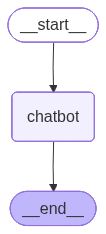

In [12]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

运行聊天机器人,通过键入 quit、exit 或 q 来退出聊天循环。

In [13]:
def stream_graph_updates(user_input: str):
    for event in graph.stream({"messages": [{"role": "user", "content": user_input}]}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)


while True:
    try:
        user_input = input("User: ")
        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break
        stream_graph_updates(user_input)
    except:
        # fallback if input() is not available
        user_input = "What do you know about LangGraph?"
        print("User: " + user_input)
        stream_graph_updates(user_input)
        break

Assistant: I'm Qwen, a large language model created by Alibaba Cloud. I'm here to help you with a wide range of tasks, from answering questions and providing information to assisting with creative writing, offering suggestions, and much more. How can I assist you today?
Assistant: LangSmith 是由 Anthropic 开发的一个工具，它主要用来帮助开发者更好地构建、测试和迭代基于 AI 的应用。这个平台特别为那些使用 Claude（Anthropic 的人工智能助手）的开发者设计，但其功能也可以支持其他类型的AI模型开发工作。

LangSmith 提供了以下几个核心功能：

1. **数据管理**：用户可以上传自己的数据集，并通过 LangSmith 平台进行管理和分析。这对于训练和优化AI模型非常有帮助。
   
2. **模型评估**：该平台允许用户对不同的AI模型进行比较和评估，包括查看模型在特定任务上的表现如何。这有助于选择最适合自己应用场景的模型版本。
   
3. **实验跟踪**：当开发者尝试不同的参数设置或算法时，LangSmith 可以帮助记录这些实验的结果，从而更容易地找到最佳实践。
   
4. **可视化工具**：提供了多种图表和报告形式来展示模型性能等信息，使得理解复杂的数据变得更加直观简单。
   
5. **协作功能**：团队成员之间可以通过 LangSmith 分享项目进展、讨论问题以及共同解决问题，促进了团队合作效率。

总之，LangSmith 是一个旨在简化AI应用开发流程的强大工具，尤其适合那些希望快速迭代并持续改进自己产品的技术团队和个人开发者。不过，请注意，由于技术和市场的发展变化迅速，建议直接访问官方文档或网站获取最新信息。
Assistant: LangSmith 是由 LangChain 团队开发的一个用于管理和监控链式应用（chain-based applications）的平台。它可以帮助开发者更高效地构建、测试和部署基于链的